<a href="https://colab.research.google.com/github/enzobanin/AnaliseDeDados/blob/main/sonoEstiloDeVida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Sono e Estilo de Vida
##Dicionário


*    Person ID: Identificador do indivíduo
*    Gender: Gênero (Masculino/Feminino).
*   Age: Idade em anos.
*  Occupation: Profissão.
*   Sleep Duration (hours): Horas de sono por dia.
*   Quality of Sleep (scale: 1-10): Qualidade do sono (escala de 1 a 10)
*   Physical Activity Level (minutes/day): Atividade física diária (minutos).
*    Stress Level (scale: 1-10): Nível de estresse (escala de 1 a 10).
*  BMI Category: Categoria de IMC.
*   Blood Pressure (systolic/diastolic): Pressão arterial (sistólica/diastólica).
*   Heart Rate (bpm): Frequência cardíaca (bpm)
*   Daily Steps: Passos por dia.
*  Sleep Disorder: Distúrbio do sono (Nenhum, Insônia, Apneia do Sono).



##Descrição geral:
Base Fictícia composta por dados sobre hábitos de sono, saúde e estilo de vida de 400 indivíduos. Pode ser
usada para explorar a relação entre qualidade de vida e distúrbios do sono.

##Desafios de análise:
*   Investigar fatores que afetam a qualidade e duração do sono.
*   Relacionar estresse e atividade física com distúrbios.
*   Analisar indicadores de saúde cardiovascular





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Colab Notebooks/sonoEstiloDeVida"

Mounted at /content/drive


In [3]:
df = pd.read_csv(path + '/02_sono_estilo_vida.csv', sep=',')
df.head(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
df.describe()
#Verificamos um alto desvio padrão em 'Daily Steps'

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


array([[<Axes: title={'center': 'Person ID'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Sleep Duration'}>],
       [<Axes: title={'center': 'Quality of Sleep'}>,
        <Axes: title={'center': 'Physical Activity Level'}>,
        <Axes: title={'center': 'Stress Level'}>],
       [<Axes: title={'center': 'Heart Rate'}>,
        <Axes: title={'center': 'Daily Steps'}>, <Axes: >]], dtype=object)

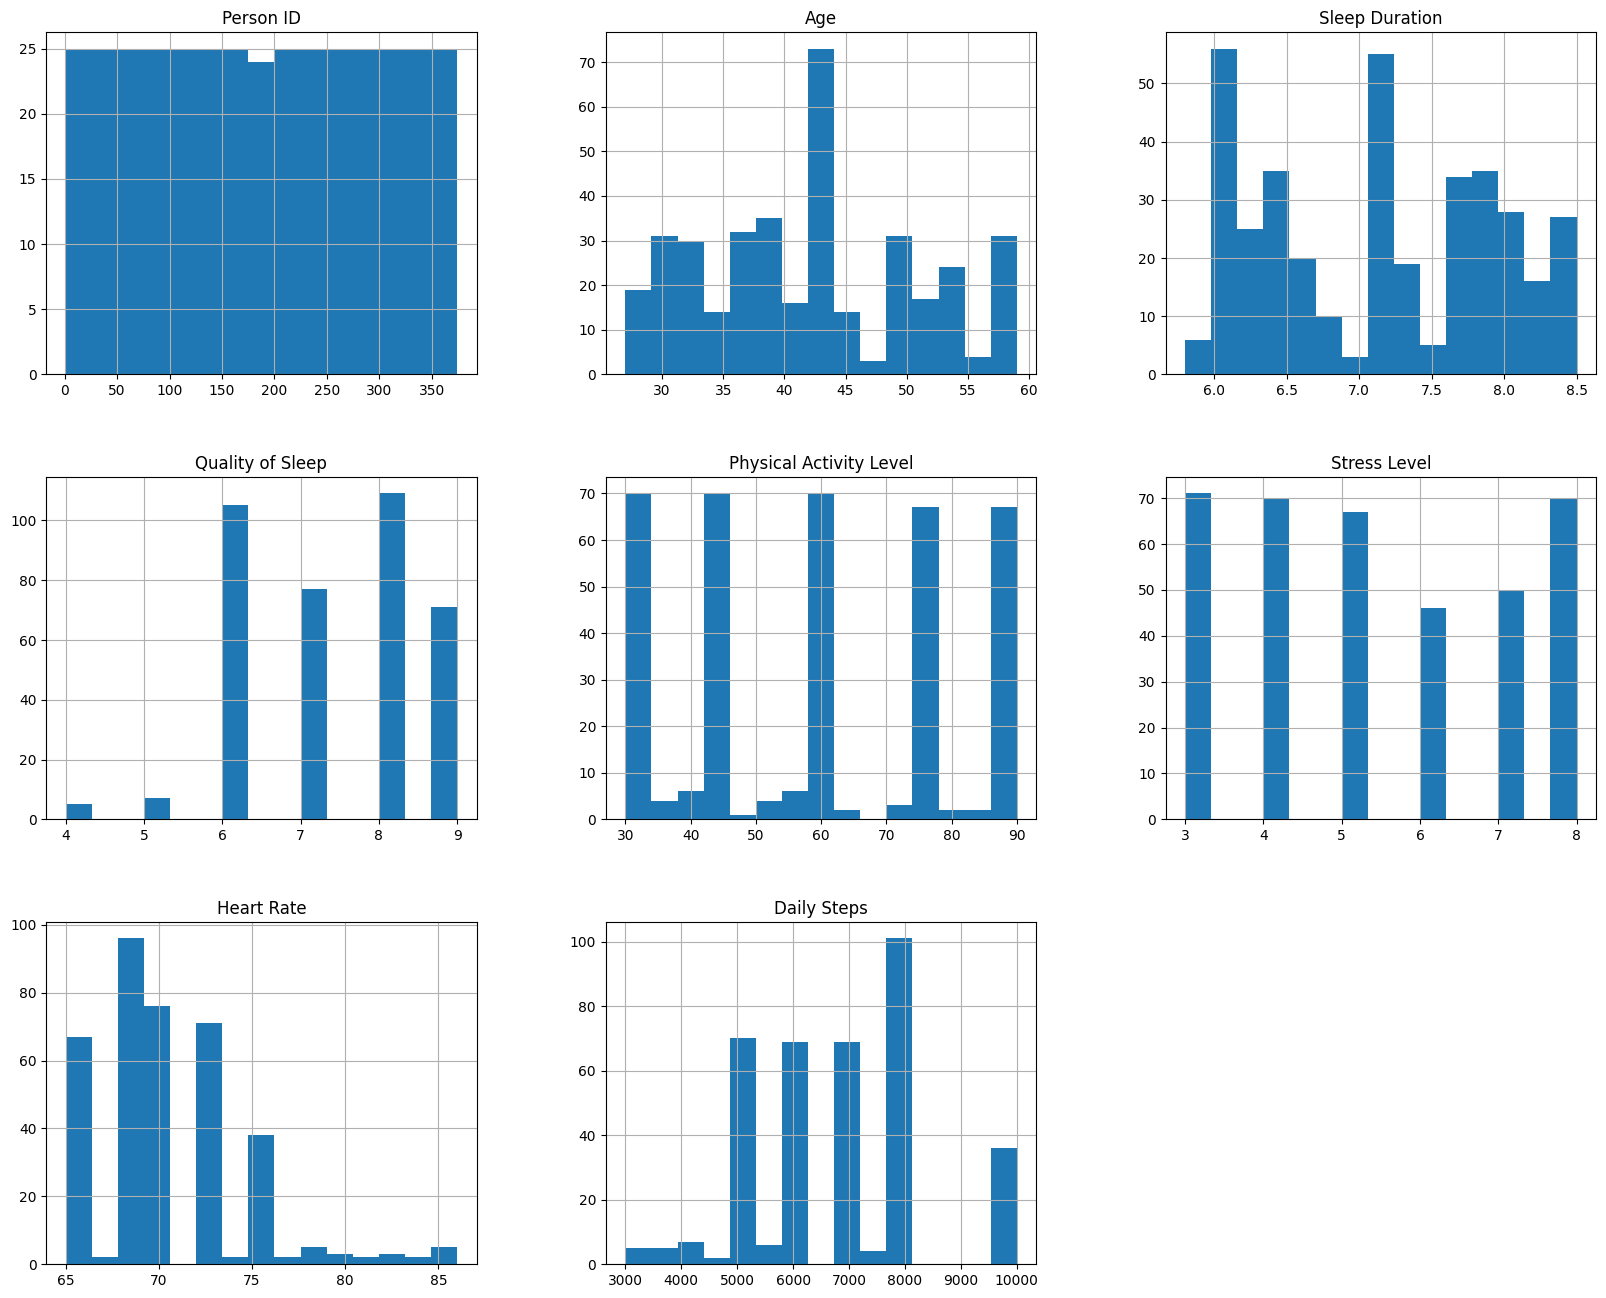

In [36]:
df.hist(bins=15, figsize=(20,16))

In [31]:
df.duplicated().sum()
#verifica os duplicados

np.int64(0)

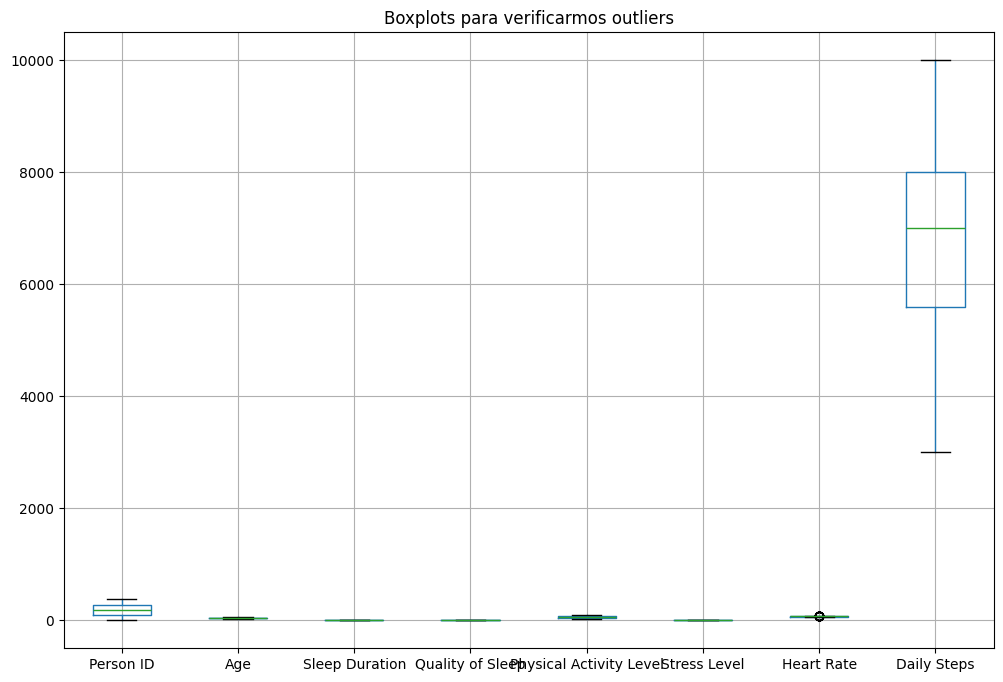

In [9]:
plt.figure(figsize=(12,8))
df.boxplot()
plt.title("Boxplots para verificarmos outliers")
plt.show()

In [6]:
#Verificando se há valores nulos
((df.isnull().sum() / df.shape[0]) * 100).sort_values(ascending=False)

,0
Sleep Disorder,58.55615
Gender,0.00000
Age,0.00000
Occupation,0.00000
Person ID,0.00000
Sleep Duration,0.00000
Quality of Sleep,0.00000
Stress Level,0.00000
Physical Activity Level,0.00000
BMI Category,0.00000


In [33]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Disorder')

In [34]:
df[df['Sleep Disorder'].isna()]
#retorna todos que não possuem Sleep Disorder

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder


In [35]:
df_without_disorder = df[df['Sleep Disorder'] == 'No Disorder']
df_without_disorder

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,No Disorder
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,No Disorder
...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Female,56,Doctor,8.2,9,90,3,Normal Weight,118/75,65,10000,No Disorder
342,343,Female,56,Doctor,8.2,9,90,3,Normal Weight,118/75,65,10000,No Disorder
343,344,Female,57,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,No Disorder
358,359,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,No Disorder


In [16]:
condicao = df[df['Quality of Sleep'] > 7]
condicao

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
32,33,Female,31,Nurse,7.9,8,75,4,Normal Weight,117/76,69,6800,NaN
50,51,Male,32,Engineer,7.5,8,45,3,Normal,120/80,70,8000,NaN
51,52,Male,32,Engineer,7.5,8,45,3,Normal,120/80,70,8000,NaN
66,67,Male,32,Accountant,7.2,8,50,6,Normal Weight,118/76,68,7000,NaN
84,85,Male,35,Software Engineer,7.5,8,60,5,Normal Weight,120/80,70,8000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [19]:
df.groupby("Gender")["Quality of Sleep"].mean()

,Quality of Sleep
Gender,
Female,7.664865
Male,6.968254


In [25]:
df.groupby(["Gender", "Occupation", "Quality of Sleep"])["BMI Category"].value_counts()

Gender  Occupation            Quality of Sleep  BMI Category 
Female  Accountant            7                 Overweight        6
                              8                 Normal           26
                                                Normal Weight     2
                              9                 Normal Weight     2
        Doctor                9                 Normal Weight     2
        Engineer              9                 Normal           32
        Lawyer                7                 Normal Weight     1
                                                Obese             1
        Manager               7                 Overweight        1
        Nurse                 5                 Normal Weight     4
                              6                 Overweight       33
                              7                 Normal Weight     1
                              8                 Normal Weight     2
                              9                 Overweight       33
        Scientist             4                 Overweight        2
                              6                 Overweight        2
        Teacher               6                 Overweight        2
                              7                 Overweight       27
                              8                 Normal            6
Male    Accountant            8                 Normal Weight     1
        Doctor                6                 Normal           33
                              7                 Normal           32
                                                Obese             2
                              9                 Obese             2
        Engineer              5                 Overweight        1
                              6                 Normal Weight     1
                              7                 Overweight        1
                              8                 Normal           24
                                                Normal Weight     3
                                                Overweight        1
        Lawyer                7                 Overweight        2
                                                Obese             1
                              8                 Normal           42
        Sales Representative  4                 Obese             2
        Salesperson           6                 Overweight       32
        Software Engineer     4                 Obese             1
                              6                 Overweight        1
                              8                 Normal Weight     2
        Teacher               5                 Overweight        2
                              6                 Obese             1
                              7                 Overweight        2
Name: count, dtype: int64

In [27]:
df.groupby(["Gender", "Quality of Sleep", "Stress Level", "Sleep Disorder"])["Daily Steps"].mean()

Gender  Quality of Sleep  Stress Level  Sleep Disorder
Female  4                 8             Sleep Apnea        5200.000000
        5                 7             Insomnia           4050.000000
                                        Sleep Apnea        4050.000000
        6                 7             Sleep Apnea        5000.000000
                          8             Insomnia          10000.000000
                                        Sleep Apnea       10000.000000
        7                 4             Insomnia           6000.000000
                          5             Sleep Apnea        3300.000000
                          6             Insomnia           6000.000000
                          7             Insomnia           6000.000000
        8                 4             Insomnia           7000.000000
                                        Sleep Apnea        7000.000000
        9                 3             Insomnia           5000.000000
                                        Sleep Apnea        7000.000000
                          4             Sleep Apnea        5000.000000
Male    4                 8             Insomnia           3000.000000
                                        Sleep Apnea        3000.000000
        5                 7             Insomnia           4400.000000
                                        Sleep Apnea        4800.000000
        6                 7             Insomnia           5916.666667
                                        Sleep Apnea        6000.000000
                          8             Insomnia           5000.000000
                                        Sleep Apnea        8000.000000
        7                 5             Insomnia           3500.000000
                                        Sleep Apnea        3300.000000
                          6             Sleep Apnea        8000.000000
                          7             Insomnia           5000.000000
        8                 5             Insomnia           8000.000000
                                        Sleep Apnea        8000.000000
        9                 3             Sleep Apnea        3700.000000
Name: Daily Steps, dtype: float64